# Deeltaak - 1
### Stap 1 — Dataset inladen


In [2]:
import pandas as pd

df = pd.read_excel("../../Dataraw/dataset.xlsx") 
df.head()

,vestnr,postcode,plaats,gemeente_code,datum_start,datum_einde,jaar,man_fte,vrouw_fte,man_pte,vrouw_pte,wp,sector_code,sbi_code,rechtsvorm,rechtsvorm_code,bagoppervlak
0,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2015,2,2,0,0,4,A,1241,Besloten Vennootschap (BV),41.0,166.0
1,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2016,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
2,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2017,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
3,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2018,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
4,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2019,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0


De dataset met werkgelegenheidsgegevens wordt ingeladen met behulp van pandas. Omdat het CSV-bestand puntkomma’s gebruikt als scheidingsteken (Excel-export), wordt sep=";" gebruikt bij het inladen.

### Stap 2 — Data Understanding

In [3]:
df["plaats"].unique()

array(['Zeewolde', 'Almere', 'Lelystad', 'Bant', 'Creil', 'Emmeloord',
       'Ens', 'Espel', 'Kraggenburg', 'Luttelgeest', 'Marknesse',
       'Nagele', 'Rutten', 'Tollebeek', 'Biddinghuizen', 'Dronten',
       'Swifterbant', 'Schokland', 'Urk'], dtype=object)

In [4]:
df.shape

(137714, 17)

df["plaats"].unique()

In [5]:
df.columns

Index(['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start',
       'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte',
       'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code',
       'bagoppervlak'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137714 entries, 0 to 137713
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   vestnr           137714 non-null  int64         
 1   postcode         137714 non-null  object        
 2   plaats           137714 non-null  object        
 3   gemeente_code    137714 non-null  int64         
 4   datum_start      137714 non-null  object        
 5   datum_einde      29225 non-null   datetime64[ns]
 6   jaar             137714 non-null  int64         
 7   man_fte          137714 non-null  int64         
 8   vrouw_fte        137714 non-null  int64         
 9   man_pte          137714 non-null  int64         
 10  vrouw_pte        137714 non-null  int64         
 11  wp               137714 non-null  int64         
 12  sector_code      137714 non-null  object        
 13  sbi_code         137714 non-null  int64         
 14  rechtsvorm       137

In deze stap wordt de dataset verkend om inzicht te krijgen in de inhoud en kwaliteit van de data.

Eerst wordt gecontroleerd of de dataset uitsluitend gegevens uit Flevoland bevat door de unieke waarden van plaats te bekijken. De uitkomst was positief.

Daarnaast wordt gecontroleerd op ontbrekende waarden met df.info(). De variabelen die relevant zijn voor deze analyse (jaar, sector_code en wp) bevatten geen ontbrekende waarden. 


### Stap 3 - Controleren van sectorindeling (SBI)
In deze stap wordt gecontroleerd of de sectorindeling in de dataset correct is opgeslagen. Hiervoor worden de unieke waarden van sector_code bekeken. Deze codes zijn gebaseerd op de Standaard Bedrijfsindeling (SBI), die economische activiteiten indeelt in verschillende sectoren.

Daarnaast worden de SBI-codes gecontroleerd op mogelijke fouten die kunnen ontstaan bij het importeren van data uit Excel, zoals het verdwijnen van voorloopnullen.

In [7]:
df["sector_code"].unique()

array(['A', 'D', 'K', 'H', 'M', 'G', 'Q', 'N', 'R', 'P', 'C', 'J', 'S',
       'E', 'I', 'O', 'F', 'L', 'B'], dtype=object)

In [8]:
df["sbi_code"].head()

0    1241
1    1241
2    1241
3    1241
4    1241
Name: sbi_code, dtype: int64

In [9]:
df["sbi_code"].astype(str).str.len().value_counts()

sbi_code
5    73134
4    57557
3     7023
Name: count, dtype: int64


Uit de controle blijkt dat de sectorcodes consistent zijn en dat de SBI-codes een lengte van 3 tot 5 cijfers hebben. Dit komt overeen met de structuur van de SBI-indeling. Er zijn daarom geen aanwijzingen dat de sectorindeling onjuist is opgeslagen of dat voorloopnullen zijn verdwenen bij het importeren van de data.

### Stap 4 - Werkgelegenheid per sector per jaar berekenen
Voor de analyse worden de variabelen jaar, sector_code en wp gebruikt. De dataset bevat werkgelegenheidsgegevens op vestigingsniveau, waarbij elke rij een vestiging in een bepaald jaar vertegenwoordigt.

Om de totale werkgelegenheid per sector per jaar te berekenen, wordt de dataset gegroepeerd op jaar en sector_code. Vervolgens wordt het aantal werkzame personen (wp) binnen elke groep opgeteld waardoor er een overzicht van de totale werkgelegenheid per sector per jaar in Flevoland onstaat.

In [10]:
df_analyse = df[["jaar","sector_code","wp"]]
df_analyse.head()

,jaar,sector_code,wp
0,2015,A,4
1,2016,A,2
2,2017,A,2
3,2018,A,2
4,2019,A,2


In [11]:
sector_trend = df_analyse.groupby(["jaar","sector_code"])["wp"].sum().reset_index()
sector_trend.head()

,jaar,sector_code,wp
0,2014,A,5053
1,2014,B,4
2,2014,C,13606
3,2014,D,251
4,2014,E,507


De tabel toont voor elk jaar en elke sector de totale werkgelegenheid. Deze dataset vormt de basis voor de verdere analyse en visualisatie van de ontwikkeling van werkgelegenheid per sector in Flevoland.

### Stap 5 - Visualisatie van werkgelegenheid per sector

In deze stap wordt de ontwikkeling van de werkgelegenheid in Flevoland gevisualiseerd, zowel per sector als in totaal. Hiervoor wordt de dataset sector_trend gebruikt, waarin de totale werkgelegenheid per sector per jaar is berekend.

Met behulp van een lijngrafiek wordt zichtbaar hoe de werkgelegenheid per sector zich door de jaren heen heeft ontwikkeld. Dit maakt het mogelijk om trends zoals groei, stabiliteit of krimp in verschillende sectoren te identificeren.

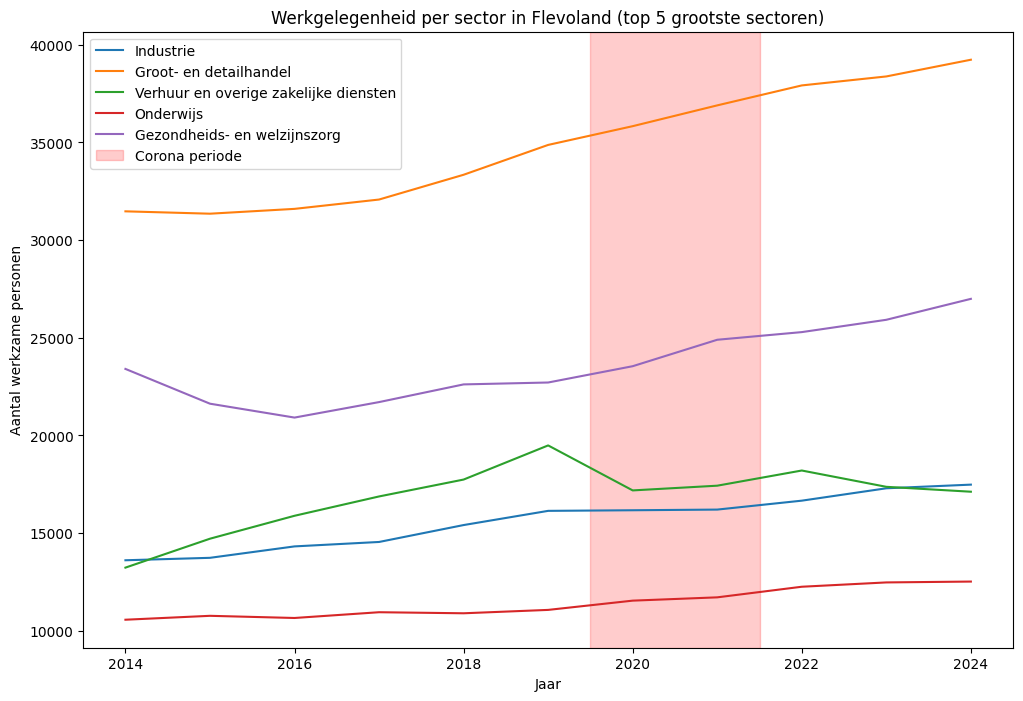

In [ ]:
import matplotlib.pyplot as plt

sector_namen = {
    "C": "Industrie",
    "G": "Groot- en detailhandel",
    "N": "Verhuur en overige zakelijke diensten",
    "P": "Onderwijs",
    "Q": "Gezondheids- en welzijnszorg"
}

top_sectoren = sector_trend.groupby("sector_code")["wp"].sum().nlargest(5).index
top_data = sector_trend[sector_trend["sector_code"].isin(top_sectoren)]

pivot = top_data.pivot(index="jaar", columns="sector_code", values="wp")

pivot = pivot.rename(columns=sector_namen)

pivot.plot(figsize=(12,8))

plt.axvspan(2019.5, 2021.5, color='red', alpha=0.2, label="Corona periode")

plt.title("Werkgelegenheid per sector in Flevoland (top 5 grootste sectoren)")
plt.xlabel("Jaar")
plt.ylabel("Aantal werkzame personen")

plt.legend()
plt.show()

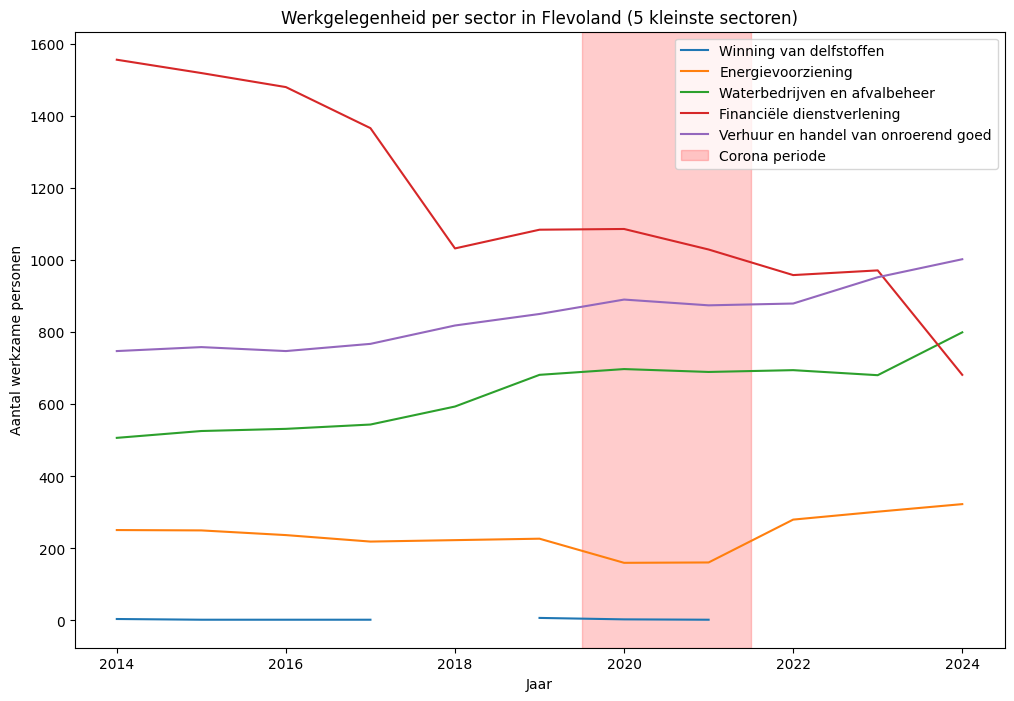

In [27]:
sector_namen = {
    "B": "Winning van delfstoffen",
    "D": "Energievoorziening",
    "E": "Waterbedrijven en afvalbeheer",
    "K": "Financiële dienstverlening",
    "L": "Verhuur en handel van onroerend goed"
}

kleinste_sectoren = sector_trend.groupby("sector_code")["wp"].sum().nsmallest(5).index
kleinste_data = sector_trend[sector_trend["sector_code"].isin(kleinste_sectoren)]

pivot = kleinste_data.pivot(index="jaar", columns="sector_code", values="wp")

# Hernoem kolommen
pivot = pivot.rename(columns=sector_namen)

pivot.plot(figsize=(12,8))

plt.axvspan(2019.5, 2021.5, color='red', alpha=0.2, label="Corona periode")

plt.title("Werkgelegenheid per sector in Flevoland (5 kleinste sectoren)")
plt.xlabel("Jaar")
plt.ylabel("Aantal werkzame personen")

plt.legend()
plt.show()

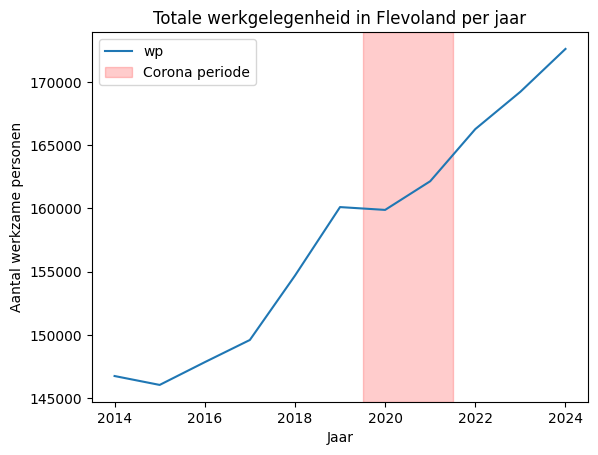

In [28]:
import matplotlib.pyplot as plt

sector_trend.groupby("jaar")["wp"].sum().plot()

plt.axvspan(2019.5, 2021.5, color='red', alpha=0.2, label="Corona periode")

plt.xlabel("Jaar")
plt.ylabel("Aantal werkzame personen")
plt.title("Totale werkgelegenheid in Flevoland per jaar")

plt.legend()  # ← dit toevoegen
plt.show()

In deze analyse wordt de periode 2014–2024 gebruikt, zodat de ontwikkeling van werkgelegenheid over een langere tijd zichtbaar is. Deze periode omvat ook de coronajaren (2020–2021), die mogelijk een vertekend beeld geven in bepaalde sectoren, zoals horeca en toerisme. Uit de grafiek blijkt dat de werkgelegenheid in de meeste sectoren op lange termijn een stijgende trend laat zien. Rond de coronaperiode is bij sommige sectoren een stagnatie of daling zichtbaar, wat waarschijnlijk het gevolg is van de genomen maatregelen en economische impact. Na deze periode is in veel sectoren weer herstel zichtbaar, wat erop wijst dat de invloed van corona tijdelijk was.

Door zowel de periode vóór, tijdens als na corona te analyseren, ontstaat een completer beeld van de structurele ontwikkeling van werkgelegenheid in Flevoland. Hierdoor kunnen tijdelijke schommelingen beter worden onderscheiden van langetermijntrends.

### Stap 6 - Analyse van ontwikkelingen
Uit de grafieken blijkt dat de werkgelegenheid in Flevoland zich over de onderzochte periode over het algemeen positief ontwikkelt. De totale werkgelegenheid laat een stijgende trend zien, wat wijst op een groei van economische activiteit in de regio.

De grootste sectoren dragen het meest bij aan de totale werkgelegenheid en bepalen grotendeels de algemene trend. In de grafiek met de vijf grootste sectoren is zichtbaar dat deze sectoren een relatief stabiele of groeiende ontwikkeling laten zien door de jaren heen.

De grafiek met de vijf kleinste sectoren laat zien dat kleinere sectoren een beperkte bijdrage leveren aan de totale werkgelegenheid. Door deze sectoren afzonderlijk te visualiseren worden ontwikkelingen zichtbaar die in de grafiek met alle sectoren minder goed opvallen. Samen geven de visualisaties een duidelijk beeld van hoe werkgelegenheid per sector zich historisch heeft ontwikkeld in Flevoland.

In [15]:
sector_trend.to_csv("../../Dataprocessed/deelvraag1_sector_trend.csv", index=False)